In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import xgboost as xgb
import shap

C:\Users\natha\PycharmProjects\ML_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [21]:
def load_data(folder_path):
    all_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

    dfs = []

    for file in all_files:
        df = pd.read_csv(os.path.join(folder_path, file), parse_dates=['Date'])
        ticker = file.split('_')[0].upper()
        df['Ticker'] = ticker
        dfs.append(df)

    data = pd.concat(dfs, ignore_index=True)
    return data

folder_path = r"C:\Users\natha\PycharmProjects\ML_Project\.venv\Dataset_clean\Stocks clean"

data = load_data(folder_path)

In [7]:
data = data.sort_values(['Ticker', 'Date'])
data.set_index('Date', inplace=True)
data['Return'] = data.groupby('Ticker')['Close'].pct_change()
ticker = data['Ticker'].unique()[0]
df = data[data['Ticker'] == ticker]

print("\n=== BASIC INFO ===")
df.head()


=== BASIC INFO ===


,Open,High,Low,Close,Volume,Ticker,Return
Date,,,,,,,
2005-02-25,92.177,93.031,92.075,92.977,5803401.0,DIA,NaN
2005-02-28,92.763,93.515,92.037,92.414,8688535.0,DIA,-0.006055
2005-03-01,92.474,93.085,92.474,92.867,6192040.0,DIA,0.004902
2005-03-02,92.511,93.266,92.456,92.728,8885876.0,DIA,-0.001497
2005-03-03,93.031,93.247,92.355,92.885,9628615.0,DIA,0.001693


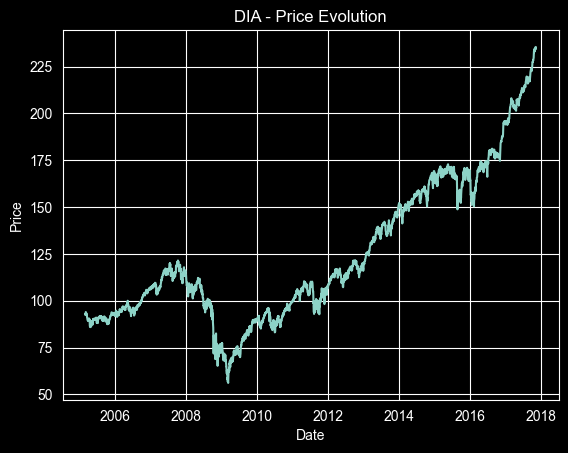

In [8]:
plt.figure()
plt.plot(df.index, df['Close'])
plt.title(f"{ticker} - Price Evolution")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

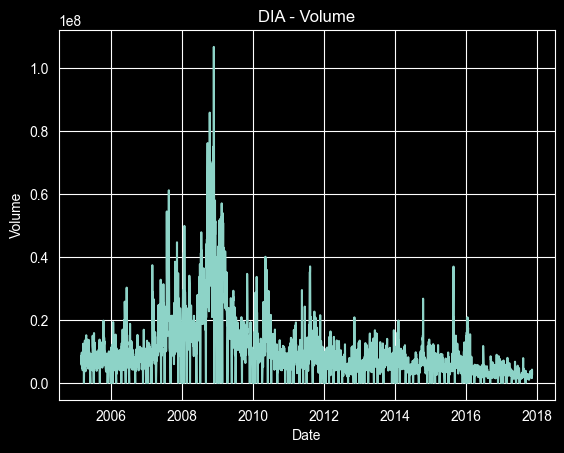

In [9]:
plt.figure()
plt.plot(df.index, df['Volume'])
plt.title(f"{ticker} - Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

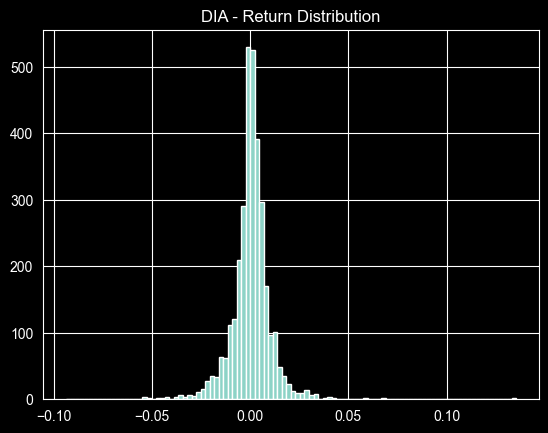

In [10]:
plt.figure()
plt.hist(df['Return'].dropna(), bins=100)
plt.title(f"{ticker} - Return Distribution")
plt.show()

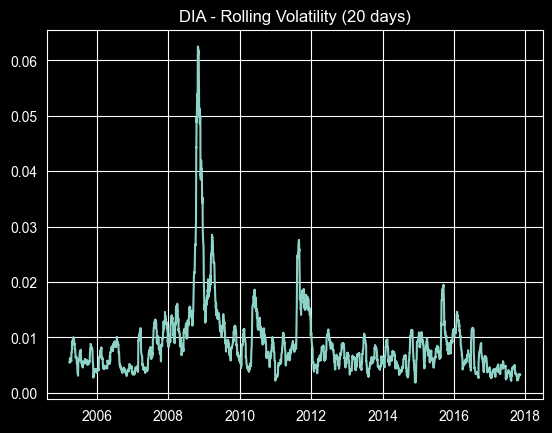

In [11]:
df = df.copy()
df['Volatility'] = df['Return'].rolling(20).std()

plt.figure()
plt.plot(df.index, df['Volatility'])
plt.title(f"{ticker} - Rolling Volatility (20 days)")
plt.show()

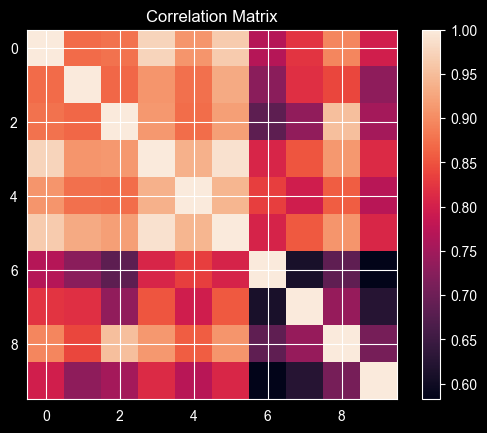

In [12]:
pivot_close = data.pivot_table(values='Close', index=data.index, columns='Ticker')

correlation_matrix = pivot_close.pct_change().corr()

plt.figure()
plt.imshow(correlation_matrix)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

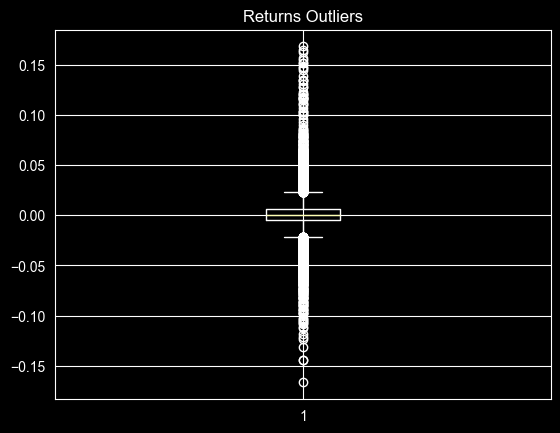

In [14]:
returns = data['Return'].dropna()

plt.figure()
plt.boxplot(returns)
plt.title("Returns Outliers")
plt.show()

In [15]:
sample_tickers = data['Ticker'].unique()[:5]

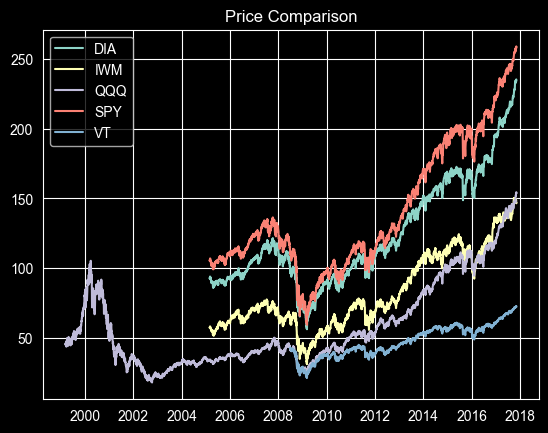

In [16]:
plt.figure()
for t in sample_tickers:
    temp = data[data['Ticker'] == t]
    plt.plot(temp.index, temp['Close'], label=t)

plt.legend()
plt.title("Price Comparison")
plt.show()

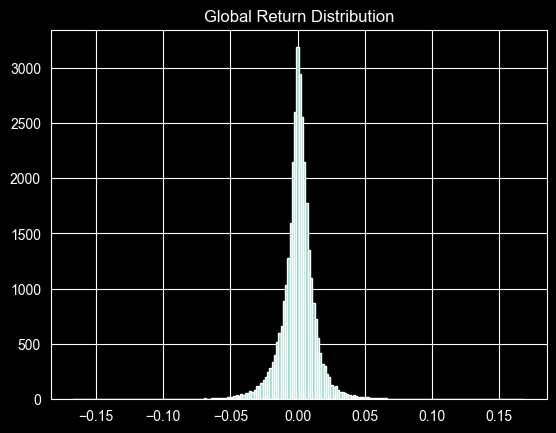

In [17]:
plt.figure()
plt.hist(data['Return'].dropna(), bins=200)
plt.title("Global Return Distribution")
plt.show()

In [18]:
print("Mean return:", data['Return'].mean())
print("Volatility:", data['Return'].std())
print("Max drawdown approx:", (data['Return'].min()))

Mean return: 0.0003583708313269343
Volatility: 0.014481357354356303
Max drawdown approx: -0.16686897848933202


In [19]:
pivot_close = data.pivot_table(values='Close', index=data.index, columns='Ticker')

pivot_close = pivot_close.sort_index()
pivot_close.ffill(inplace=True)
pivot_close.dropna(inplace=True)

print(f"Dataset prêt avec {pivot_close.shape[1]} actifs.")

returns_df = np.log(1 + pivot_close.pct_change())


Dataset prêt avec 10 actifs.


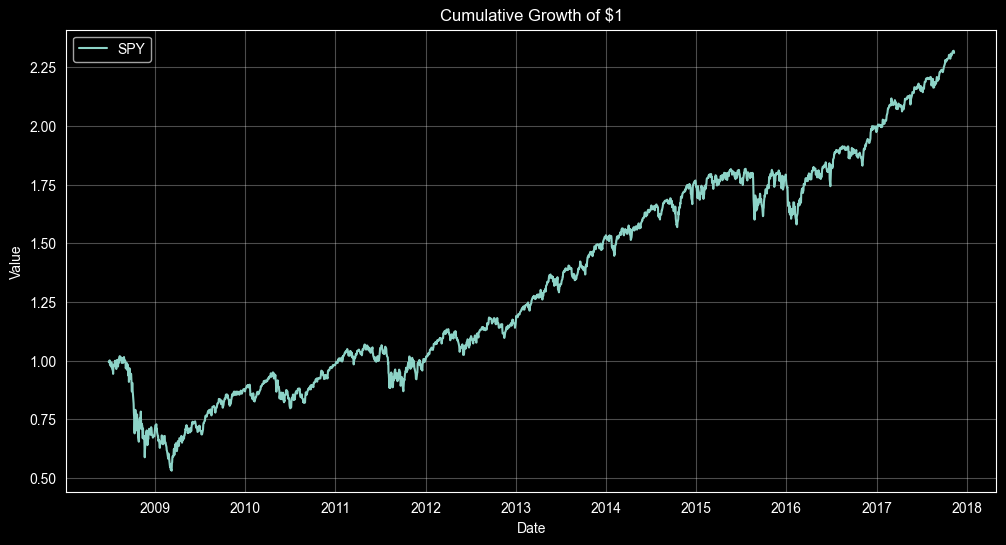

In [20]:
returns_df = np.log(1 + pivot_close.pct_change())

vol_df = returns_df.rolling(window=21).std()

cum_returns = returns_df.cumsum().apply(np.exp)

plt.figure(figsize=(12, 6))

# Vérification que les tickers existent
for ticker in ['SPY', 'NVDA', 'XOM']:
    if ticker in cum_returns.columns:
        plt.plot(cum_returns[ticker], label=ticker)

plt.title("Cumulative Growth of $1")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [32]:


y = (returns_df['AAPL'].shift(-1) > 0).astype(int)

features = [c for c in ['BA', 'AMZN', 'AMD', 'XLF', 'AAPL', 'ABBV', 'NVDA'] if c in returns_df.columns]

X = returns_df[features].iloc[:-1]
y = y.iloc[:-1]


split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [33]:

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

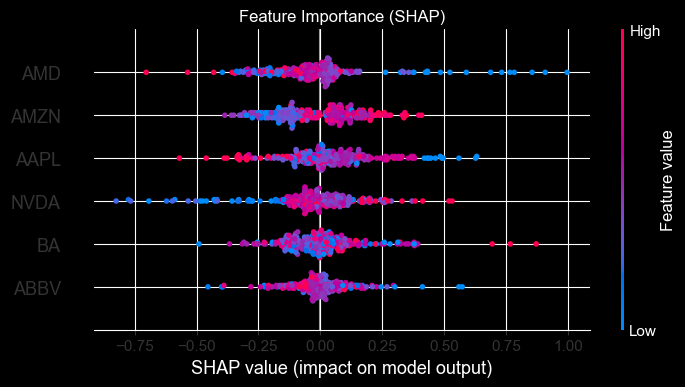

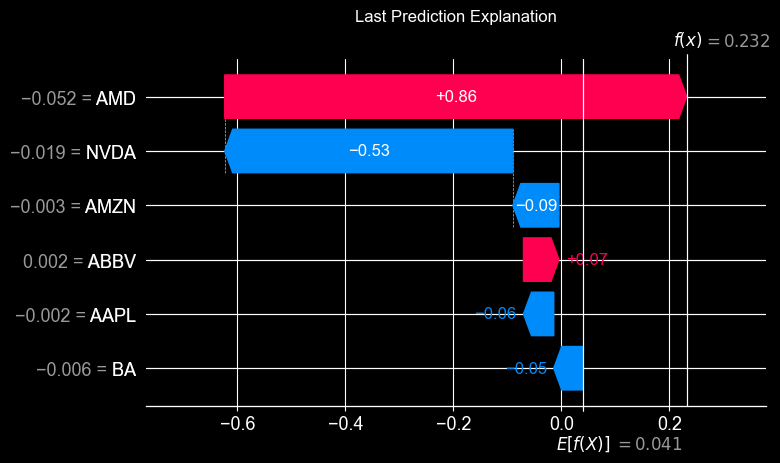

In [34]:
plt.title("Feature Importance (SHAP)")
shap.plots.beeswarm(shap_values)

plt.title("Last Prediction Explanation")
shap.plots.waterfall(shap_values[-1])